## Foreign Gifts: UVA Analysis
#### *Name: Anna Phillips*

In [2]:
## Set up
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **A. Initial UVA Data Exploration**
- overview of gift count, gift mean, and gift type
- explore top countries and donors

In [80]:
## 1. Load the data
df = pd.read_csv('ForeignGifts_edu.csv', low_memory = False)

# Asked ChatGPT what the date format meant and how to convert it
df["Foreign Gift Received Date"] = pd.to_datetime(
    df["Foreign Gift Received Date"],
    unit="D",
    origin="1899-12-30"
)
# What's the date range for this data frame?
display(df["Foreign Gift Received Date"].agg(["min", "max"]))



min   2014-01-01
max   2020-06-30
Name: Foreign Gift Received Date, dtype: datetime64[s]

***Important Takeaway***: *All of the gifts transactions in this data set occurred in the timeframe of 2014-2020. This seems to be a snapshot of available data, so we can't get a full picture of potential trends, but exploring repeated donors is still meaningful.*

In [79]:
# Snapshot of all UVA gifts
uva = df[df["Institution Name"] == "University of Virginia"]

display(uva.head())
print(f"{uva.shape[0]} total gifts")

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,2014-07-02,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,2014-08-19,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,2014-08-22,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,2014-09-05,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,2014-09-22,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd


98 total gifts


In [74]:
# break down of contracts vs monetary gifts for UVA
display(uva.groupby("Gift Type")["Foreign Gift Amount"].describe())

uva["Foreign Gift Received Date"].agg(["min", "max"])

,count,mean,std,min,25%,50%,75%,max
Gift Type,,,,,,,,
Contract,64.0,231369.312500,370082.07040,31.0,9813.75,92130.5,259627.50,1708021.0
Monetary Gift,34.0,217105.941176,291247.23109,223.0,8290.50,67271.5,308750.75,1000000.0


min   2014-07-02
max   2019-12-19
Name: Foreign Gift Received Date, dtype: datetime64[s]

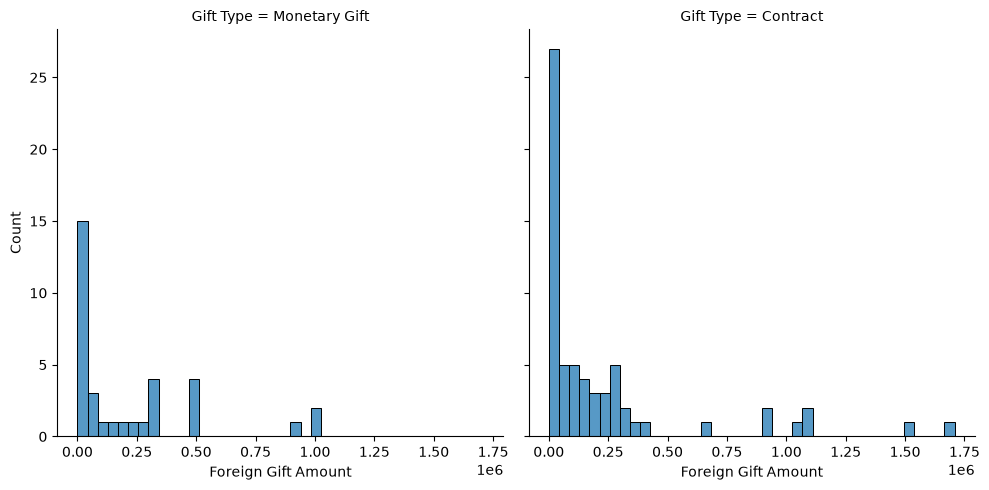

In [36]:
sns.displot(
    data=uva,
    x="Foreign Gift Amount",
    col="Gift Type",
    bins=40,
    facet_kws={"sharex": True, "sharey": True}
)
plt.show()

#### *Explore countries vs. individuals donors*
- top donor by count vs. sum
- how many individual donors are associated with each country

In [64]:
# See how many giftors are associated with more than one country
giftor_country_counts = (
    df.groupby("Giftor Name")["Country of Giftor"]
    .nunique()
)

display(giftor_country_counts.sort_values(ascending=False).head().reset_index())

va_giftor_country_counts = (
    va_schools.groupby("Giftor Name")["Country of Giftor"]
    .nunique()
)
display(va_giftor_country_counts.sort_values(ascending=False).head().reset_index())

print(f"Full dataframe: {(giftor_country_counts > 1).sum()} donors associated with more than one country")
print(f"Virginia schools only: {(va_giftor_country_counts > 1).sum()} donors associated with more than one country")

,Giftor Name,Country of Giftor
0,Anonymous,44
1,Contracting Party,17
2,Corporation,14
3,Individual,14
4,Government,13


,Giftor Name,Country of Giftor
0,AO Foundation,1
1,Actelion,1
2,Adelphi Group Limited,1
3,"Allergan, Inc.",1
4,Anhui Zhifei Longcom Biopharmaceuti,1


Full dataframe: 218 donors associated with more than one country
Virginia schools only: 0 donors associated with more than one country


***Important Takeaway***: *For Virginia-level analysis, there's no individual donor associated with multiple countries, which makes comparison between UVA and Virginia schools simpler.*

In [ ]:
# How many unique countries and unique donors give to UVA?
print(f"Unique countries: {uva["Country of Giftor"].nunique()}")
print(f"Unique giftors: {uva["Giftor Name"].nunique()}")

Unique countries: 15
Unique giftors: 58


In [129]:
uva.groupby(["Country of Giftor", "Giftor Name"])["Foreign Gift Amount"].sum().sort_index(level="Country of Giftor").reset_index().groupby("Country of Giftor").head(2)

,Country of Giftor,Giftor Name,Foreign Gift Amount
0,BANGLADESH,International Centre for Diarrhoeal,919518
1,BANGLADESH,Intl Ctr for Diarrhoeal Disease,310001
5,BERMUDA,Hemera Foundation,900000
6,ENGLAND,Adelphi Group Limited,9750
7,ENGLAND,Charities Aid Foundation,727928
20,FINLAND,Danisco Sweeteners Oy,990331
21,FINLAND,FKD Therapies Oy,18053
22,FRANCE,Biom 'Up,5250
23,FRANCE,Genfit,19185
26,GUERNSEY,Harvest Group Holding,1000000


***Important Takeaway***: *Individual donor number (58) is not accurate due to different naming conventions for the same giftor (e.g., "Haydom Luther Hospital" vs. "Haydom Lutheran Hospital").*

In [182]:
# Highest UVA donor countries by gift count
display(uva.groupby("Country of Giftor")["Foreign Gift Amount"].describe().sort_values(by='count', ascending=False).head(10))

# Highest UVA donor countries by total gift sum
display(uva.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(10).reset_index())

# Highest UVA giftor by gift count
display(uva.groupby(["Country of Giftor", "Giftor Name"])["Foreign Gift Amount"].describe().sort_values(by='count', ascending=False).head(10))

# Highest UVA giftor countries by total sum
display(uva.groupby(["Country of Giftor", "Giftor Name"])["Foreign Gift Amount"].sum().sort_values(ascending=False).head(10).reset_index())

,count,mean,std,min,25%,50%,75%,max
Country of Giftor,,,,,,,,
ENGLAND,31.0,62924.709677,86767.660725,223.0,8767.00,20982.0,68496.00,321029.0
ISRAEL,12.0,51971.250000,89549.598060,2650.0,6843.50,11010.5,31577.75,263250.0
BANGLADESH,10.0,422858.900000,409172.259567,31.0,69125.50,307225.5,794958.00,1077948.0
SWEDEN,10.0,400755.200000,640447.785631,5056.0,41651.25,133055.0,207028.75,1708021.0
FINLAND,7.0,144054.857143,154222.529150,1493.0,8280.00,84376.0,267967.50,370020.0
KOREA,6.0,143797.833333,119685.494856,8333.0,59421.00,122467.0,220049.75,318537.0
FRANCE,5.0,50076.600000,57445.931691,5250.0,9350.00,9835.0,112470.00,113478.0
THE NETHERLANDS,4.0,181417.500000,43374.558199,146810.0,146810.00,171089.5,205697.00,236681.0
GUERNSEY,3.0,500000.000000,0.000000,500000.0,500000.00,500000.0,500000.00,500000.0


,Country of Giftor,Foreign Gift Amount
0,BANGLADESH,4228589
1,SWEDEN,4007552
2,TANZANIA,2776447
3,SWITZERLAND,2000000
4,ENGLAND,1950666
5,GUERNSEY,1500000
6,FINLAND,1008384
7,BERMUDA,900000
8,KOREA,862787
9,SINGAPORE,805000


count           mean  \
Country of Giftor Giftor Name                                                
ENGLAND           Kirkhouse Trust                       9.0   40717.777778   
SWEDEN            AutoLiv Development AB                5.0  137043.400000   
FINLAND           Danisco Sweeteners Oy                 4.0  247582.750000   
ENGLAND           University of Newcastle               4.0   27415.750000   
FINLAND           FKD Therapies Oy                      3.0    6017.666667   
ENGLAND           Charities Aid Foundation              3.0  242642.666667   
                  GW Research Ltd                       3.0   18808.333333   
BANGLADESH        Intl. Cntr for Diarrihoeal Disease    3.0  232105.666667   
                  Intrnl Centre Diarrheal Disease       3.0  460965.333333   
ENGLAND           London School of Economics            3.0   20970.333333   

                                                                std       min  \
Country of Giftor Giftor Name                                                   
ENGLAND           Kirkhouse Trust                      42294.326427    3071.0   
SWEDEN            AutoLiv Development AB               85802.061387    5056.0   
FINLAND           Danisco Sweeteners Oy               119220.676354   84376.0   
ENGLAND           University of Newcastle              27463.192062     223.0   
FINLAND           FKD Therapies Oy                      3995.354344    1493.0   
ENGLAND           Charities Aid Foundation             50115.801593  211622.0   
                  GW Research Ltd                      14353.549886    7850.0   
BANGLADESH        Intl. Cntr for Diarrihoeal Disease  213875.469389      31.0   
                  Intrnl Centre Diarrheal Disease     555515.447851     498.0   
ENGLAND           London School of Economics           12031.504242    8933.0   

                                                           25%       50%  \
Country of Giftor Giftor Name                                              
ENGLAND           Kirkhouse Trust                       8601.0   15621.0   
SWEDEN            AutoLiv Development AB               99885.0  166225.0   
FINLAND           Danisco Sweeteners Oy               214909.0  267967.5   
ENGLAND           University of Newcastle              15751.0   21903.5   
FINLAND           FKD Therapies Oy                      4496.5    7500.0   
ENGLAND           Charities Aid Foundation            213734.0  215846.0   
                  GW Research Ltd                      10684.5   13519.0   
BANGLADESH        Intl. Cntr for Diarrihoeal Disease  137519.5  275008.0   
                  Intrnl Centre Diarrheal Disease     152474.0  304450.0   
ENGLAND           London School of Economics           14957.5   20982.0   

                                                            75%        max  
Country of Giftor Giftor Name                                               
ENGLAND           Kirkhouse Trust                      68082.00   128195.0  
SWEDEN            AutoLiv Development AB              207019.00   207032.0  
FINLAND           Danisco Sweeteners Oy               300641.25   370020.0  
ENGLAND           University of Newcastle              33568.25    65633.0  
FINLAND           FKD Therapies Oy                      8280.00     9060.0  
ENGLAND           Charities Aid Foundation            258153.00   300460.0  
                  GW Research Ltd                      24287.50    35056.0  
BANGLADESH        Intl. Cntr for Diarrihoeal Disease  348143.00   421278.0  
                  Intrnl Centre Diarrheal Disease     691199.00  1077948.0  
ENGLAND           London School of Economics           26989.00    32996.0

,Country of Giftor,Giftor Name,Foreign Gift Amount
0,SWEDEN,AstraZeneca,3208048
1,BANGLADESH,Intrnl Centre Diarrheal Disease,1382896
2,TANZANIA,Haydom Lutheran Hospital d/b/a Hayd,1100553
3,TANZANIA,Haydom Luther Hospital,1035339
4,GUERNSEY,Harvest Group Holding,1000000
5,SWITZERLAND,Lawrence D/ Karin S Howell,1000000
6,SWITZERLAND,Lawrence D & Karin S Howell,1000000
7,FINLAND,Danisco Sweeteners Oy,990331
8,BANGLADESH,Intnl Centre for Diarrhoeal Disease,919857
9,BANGLADESH,International Centre for Diarrhoeal,919518


***Important Takeaway***: *England has given us the most gifts by count (31), and Bangladesh has given us the most money overall ($4,228,589).*

In [96]:
display(
    uva["Foreign Gift Received Date"].agg(["min", "max"])
)

display(
    uva["Foreign Gift Received Date"]
    .dt.year
    .value_counts()
    .sort_index()
)

min   2014-07-02
max   2019-12-19
Name: Foreign Gift Received Date, dtype: datetime64[s]

Foreign Gift Received Date
2014    15
2015    10
2016    31
2017    25
2018     9
2019     8
Name: count, dtype: int64

In [97]:
country_year_summary = (
    uva.groupby("Country of Giftor")
    .agg(
        years=("Foreign Gift Received Date",
               lambda x: sorted(x.dt.year.unique())),
        n_years=("Foreign Gift Received Date",
                 lambda x: x.dt.year.nunique()),
        gift_count=("Gift Type", "count"),
        gift_sum=("Foreign Gift Amount", "sum")
    )
    .sort_values("gift_sum", ascending=False)
)

display(country_year_summary)

,years,n_years,gift_count,gift_sum
Country of Giftor,,,,
BANGLADESH,"[2014, 2015, 2016, 2017, 2019]",5,10,4228589
SWEDEN,"[2015, 2016, 2018, 2019]",4,10,4007552
TANZANIA,"[2017, 2018]",2,3,2776447
SWITZERLAND,[2019],1,2,2000000
ENGLAND,"[2014, 2015, 2016, 2017]",4,31,1950666
GUERNSEY,"[2017, 2018, 2019]",3,3,1500000
FINLAND,"[2016, 2017, 2018]",3,7,1008384
BERMUDA,[2016],1,1,900000
KOREA,"[2015, 2016]",2,6,862787


***Important Takeaway***: *Focus on countries/giftors with repeated donations when looking at potential new foreign donors for UVA. In our current donor list, Bangladesh, Sweden, and England have given most consistently over the years.*

### **Initial UVA Exploration Summary**
- 98 observations of gifts:
    - 64 contracts ($231,369 average) vs 34 monetary gifts ($217,105 average)
        - Gifts were spread over 2014-2019 (some countries were consistent givers and some weren't)
    - 15 unique countries
        - Analysis initially showed *58 unique giftors*, but further investigation revealed this number to be inflated due to inconsistent naming conventions (plan for exploring the giftor variable will depend on comparison between UVA and other Virginia schools)

### **A. UVA vs. Other Virginia Schools Exploration**
- overview of gift count, gift mean, and gift type
- explore top countries and donors differences

In [131]:
# Dollar amount of total gifts
va_schools = df[df["State"] == "VA"]

print(va_schools.shape)

display(va_schools.head())

va_school_summary = (
    va_schools
    .groupby("Institution Name")
    .agg(
        Gift_Count=("Gift Type", "count"),
        Total_Amount=("Foreign Gift Amount", "sum"),
        Total_Countries=("Country of Giftor", "nunique")
    )
    .sort_values("Total_Amount", ascending=False)
    .reset_index()
)

display(va_school_summary)

(292, 10)


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26103,26104,370500,College of William & Mary,Williamsburg,VA,2016-03-23,19613,Monetary Gift,CHINA,Hanban
26104,26105,370500,College of William & Mary,Williamsburg,VA,2016-03-23,18695,Monetary Gift,CHINA,Hanban
26105,26106,370500,College of William & Mary,Williamsburg,VA,2016-06-21,556,Monetary Gift,CHINA,Hanban
26106,26107,370500,College of William & Mary,Williamsburg,VA,2016-09-30,10380,Monetary Gift,CHINA,Hanban
26107,26108,370500,College of William & Mary,Williamsburg,VA,2016-12-07,51600,Monetary Gift,CHINA,Hanban


,Institution Name,Gift_Count,Total_Amount,Total_Countries
0,Virginia Commonwealth University,115,89163583,23
1,George Mason University,38,65435604,10
2,University of Virginia,98,22189238,15
3,Virginia Polytechnic Institute & State University,24,11792062,14
4,College of William & Mary,17,3384498,3


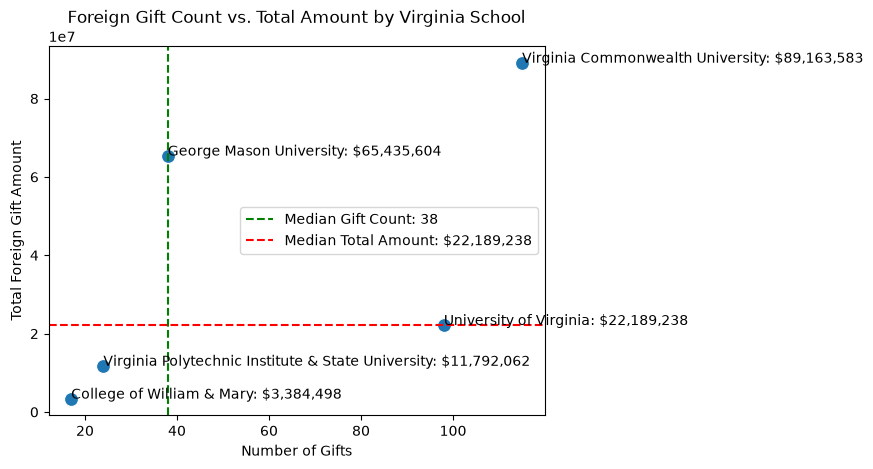

In [202]:
gift_count_median = va_school_summary["Gift_Count"].median()
gift_sum_median = va_school_summary["Total_Amount"].median()

sns.scatterplot(
    data=va_school_summary,
    x="Gift_Count",
    y="Total_Amount",
    s=100
)

# quadrant lines
plt.axvline(
    gift_count_median,
    linestyle="--",
    c="green",
    label=f"Median Gift Count: {gift_count_median:.0f}"
)

plt.axhline(
    gift_sum_median,
    linestyle="--",
    c="red",
    label=f"Median Total Amount: ${gift_sum_median:,.0f}"
)

# school labels
for _, row in va_school_summary.iterrows():
    plt.text(
        row["Gift_Count"],
        row["Total_Amount"],
        f"{row['Institution Name']}: ${row['Total_Amount']:,.0f}"
    )

plt.xlabel("Number of Gifts")
plt.ylabel("Total Foreign Gift Amount")
plt.title("Foreign Gift Count vs. Total Amount by Virginia School")
plt.legend()

plt.show()

***Takeaways***: *There's a big discrepancy between schools in terms of total gift amount and gift count. UVA receives the second highest count of gifts, but fall way behind GMU and VCU in terms of total gift sum. 

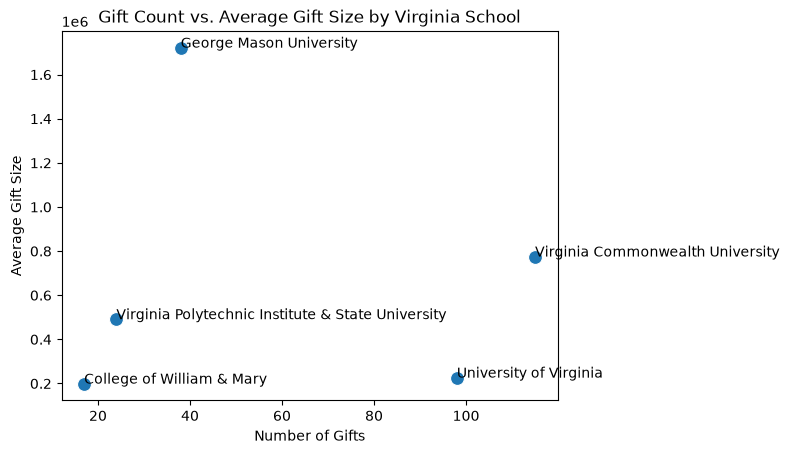

In [215]:
va_school_summary["Avg_Gift"] = (
    va_school_summary["Total_Amount"] /
    va_school_summary["Gift_Count"]
)

sns.scatterplot(
    data=va_school_summary,
    x="Gift_Count",
    y="Avg_Gift",
    s=100
)

for _, row in va_school_summary.iterrows():
    plt.text(
        row["Gift_Count"],
        row["Avg_Gift"],
        row["Institution Name"]
    )

plt.xlabel("Number of Gifts")
plt.ylabel("Average Gift Size")
plt.title("Gift Count vs. Average Gift Size by Virginia School")

plt.show()

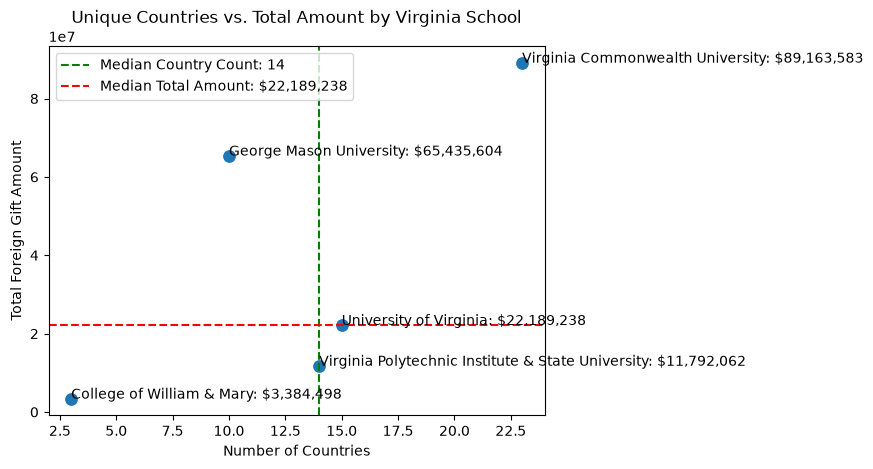

In [212]:
country_count_median = va_school_summary["Total_Countries"].median()
gift_sum_median = va_school_summary["Total_Amount"].median()

sns.scatterplot(
    data=va_school_summary,
    x="Total_Countries",
    y="Total_Amount",
    s=100
)

# quadrant lines
plt.axvline(
    country_count_median,
    linestyle="--",
    c="green",
    label=f"Median Country Count: {country_count_median:.0f}"
)

plt.axhline(
    gift_sum_median,
    linestyle="--",
    c="red",
    label=f"Median Total Amount: ${gift_sum_median:,.0f}"
)

# school labels
for _, row in va_school_summary.iterrows():
    plt.text(
        row["Total_Countries"],
        row["Total_Amount"],
        f"{row['Institution Name']}: ${row['Total_Amount']:,.0f}"
    )

plt.xlabel("Number of Countries")
plt.ylabel("Total Foreign Gift Amount")
plt.title("Unique Countries vs. Total Amount by Virginia School")
plt.legend()

plt.show()

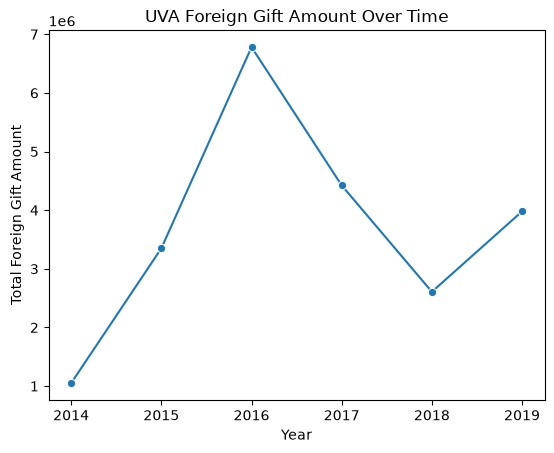

In [135]:
uva_by_year = (
    uva.assign(
        Year=uva["Foreign Gift Received Date"].dt.year
    )
    .groupby("Year")["Foreign Gift Amount"]
    .sum()
    .reset_index()
)

sns.lineplot(
    data=uva_by_year,
    x="Year",
    y="Foreign Gift Amount",
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Total Foreign Gift Amount")
plt.title("UVA Foreign Gift Amount Over Time")

plt.show()

In [136]:
gift_counts_by_year = (
    va_schools
    .assign(
        Year=va_schools["Foreign Gift Received Date"].dt.year
    )
    .groupby(["Institution Name", "Year"])
    .size()
    .reset_index(name="Gift Count")
)

display(gift_counts_by_year.head())

,Institution Name,Year,Gift Count
0,College of William & Mary,2016,6
1,College of William & Mary,2017,3
2,College of William & Mary,2018,5
3,College of William & Mary,2019,3
4,George Mason University,2014,4


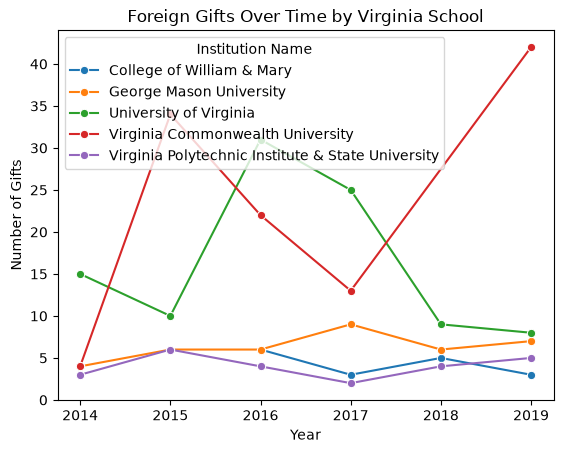

In [137]:
sns.lineplot(
    data=gift_counts_by_year,
    x="Year",
    y="Gift Count",
    hue="Institution Name",
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Gifts")
plt.title("Foreign Gifts Over Time by Virginia School")

plt.show()

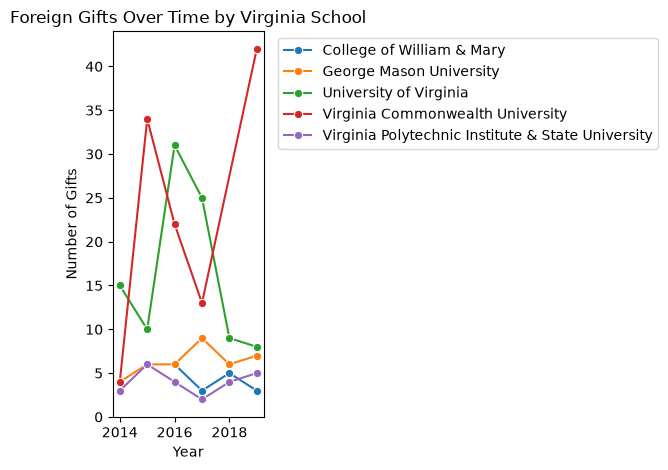

In [138]:
sns.lineplot(
    data=gift_counts_by_year,
    x="Year",
    y="Gift Count",
    hue="Institution Name",
    marker="o"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xlabel("Year")
plt.ylabel("Number of Gifts")
plt.title("Foreign Gifts Over Time by Virginia School")

plt.tight_layout()
plt.show()

In [139]:
school_summary = (
    va_schools.groupby("Institution Name")
    .agg(
        gift_count=("Foreign Gift Amount", "count"),
        gift_sum=("Foreign Gift Amount", "sum")
    )
    .reset_index()
)

display(school_summary)

,Institution Name,gift_count,gift_sum
0,College of William & Mary,17,3384498
1,George Mason University,38,65435604
2,University of Virginia,98,22189238
3,Virginia Commonwealth University,115,89163583
4,Virginia Polytechnic Institute & State University,24,11792062


In [94]:
# Gifts by type by VA school
va_schools.groupby("Institution Name")["Gift Type"].value_counts().reset_index()

,Institution Name,Gift Type,count
0,College of William & Mary,Monetary Gift,17
1,George Mason University,Contract,38
2,University of Virginia,Contract,64
3,University of Virginia,Monetary Gift,34
4,Virginia Commonwealth University,Contract,115
5,Virginia Polytechnic Institute & State University,Contract,24


In [19]:
# How many unique countries donate to each VA school
va_schools.groupby("Institution Name")["Country of Giftor"].nunique().sort_values(ascending=False).reset_index()

,Institution Name,Country of Giftor
0,Virginia Commonwealth University,23
1,University of Virginia,15
2,Virginia Polytechnic Institute & State University,14
3,George Mason University,10
4,College of William & Mary,3


In [ ]:
# VA schools by highest total donor
va_schools.groupby(['Institution Name', 'Country of Giftor'])["Foreign Gift Amount"].sum().reset_index().sort_values(["Institution Name", "Foreign Gift Amount"],ascending=[True, False]).groupby("Institution Name").head(1)

,Institution Name,Country of Giftor,Foreign Gift Amount
2,College of William & Mary,SAUDI ARABIA,2262530
10,George Mason University,SAUDI ARABIA,54183796
13,University of Virginia,BANGLADESH,4228589
43,Virginia Commonwealth University,QATAR,78867097
53,Virginia Polytechnic Institute & State University,ENGLAND,2586931


In [23]:
# VA schools by highest single donation

va_schools.groupby(['Institution Name', 'Country of Giftor'])['Foreign Gift Amount'].max().sort_values(ascending=False).groupby(level=0).head(1).reset_index()

,Institution Name,Country of Giftor,Foreign Gift Amount
0,Virginia Commonwealth University,QATAR,40092588
1,George Mason University,SAUDI ARABIA,5668346
2,Virginia Polytechnic Institute & State University,ENGLAND,1750000
3,University of Virginia,SWEDEN,1708021
4,College of William & Mary,SAUDI ARABIA,932265


In [219]:
uva_donors = (
    uva[["Country of Giftor", "Giftor Name"]]
    .drop_duplicates()
)

other_va = (
    va_schools[
        va_schools["Institution Name"] != "University of Virginia"
    ]
)

non_uva_donors = (
    other_va
    .merge(
        uva_donors,
        on=["Country of Giftor", "Giftor Name"],
        how="left",
        indicator=True
    )
    .query('_merge == "left_only"')
    .drop(columns="_merge")
)

non_uva_donor_summary = (
    non_uva_donors
    .groupby([
        "Institution Name",
        "Country of Giftor",
        "Giftor Name"
    ])
    .agg(
        gift_count=("Foreign Gift Amount", "count"),
        total_sum=("Foreign Gift Amount", "sum")
    )
    .reset_index()
    .sort_values("total_sum", ascending=False)
    .head(15)
)

display(non_uva_donor_summary)

,Institution Name,Country of Giftor,Giftor Name,gift_count,total_sum
67,Virginia Commonwealth University,QATAR,Qatar Foundation,3,78285875
13,George Mason University,SAUDI ARABIA,Royal Embassy of Saudi Arabia,12,54183796
18,George Mason University,UNITED ARAB EMIRATES,Embassy of the United Arab Emirates,6,4406188
4,College of William & Mary,SAUDI ARABIA,Royal Embassy of Saudi Arabia/SACM,4,2262530
88,Virginia Polytechnic Institute & State University,ENGLAND,Indivior UK Limited,1,1750000
49,Virginia Commonwealth University,GERMANY,Boehringer Ingelheim Pharmaceutical,5,1489324
100,Virginia Polytechnic Institute & State University,SPAIN,ISGlobal,1,1408507
9,George Mason University,KUWAIT,Embassy of the State of Kuwait,4,1388173
17,George Mason University,UNITED ARAB EMIRATES,Embassy of The UAE - Police Attache,2,1128033
99,Virginia Polytechnic Institute & State University,OMAN,OTE Group of Companies,2,1099939


In [ ]:
# Key comparisons table



In [69]:
# Visual breakdown of top UVA donors (Countries)

import pandas as pd
import plotly.graph_objects as go


giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    uva.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

***Important Takeaway***: *UVA's donor distribution is made up of more countries with similar donation amounts, compared to VCU and GMU (shown below), who get the majority of their money from one donor (Qatar and Saudia Arabia respectively).*

In [34]:
import pandas as pd
import plotly.graph_objects as go


giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    va_schools.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

In [158]:
va_schools[(va_schools["Country of Giftor"] == "QATAR") | (va_schools["Country of Giftor"] == "SAUDI ARABIA")]

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26108,26109,370500,College of William & Mary,Williamsburg,VA,2016-12-31,416266,Monetary Gift,SAUDI ARABIA,Royal Embassy of Saudi Arabia/SACM
26111,26112,370500,College of William & Mary,Williamsburg,VA,2017-12-31,932265,Monetary Gift,SAUDI ARABIA,Royal Embassy of Saudi Arabia/SACM
26116,26117,370500,College of William & Mary,Williamsburg,VA,2018-12-31,303978,Monetary Gift,SAUDI ARABIA,Royal Embassy of Saudi Arabia/SACM
26118,26119,370500,College of William & Mary,Williamsburg,VA,2019-12-31,610021,Monetary Gift,SAUDI ARABIA,Royal Embassy of Saudi Arabia/SACM
26125,26126,373500,Virginia Commonwealth University,Richmond,VA,2015-03-05,272980,Contract,QATAR,Qatar National Research Fund
26126,26127,373500,Virginia Commonwealth University,Richmond,VA,2015-03-05,270954,Contract,QATAR,Qatar National Research Fund
26127,26128,373500,Virginia Commonwealth University,Richmond,VA,2015-04-01,7392,Contract,QATAR,Qatar National Research Fund
26128,26129,373500,Virginia Commonwealth University,Richmond,VA,2015-04-01,7605,Contract,QATAR,Qatar National Research Fund
26129,26130,373500,Virginia Commonwealth University,Richmond,VA,2015-04-01,7689,Contract,QATAR,Qatar University
26130,26131,373500,Virginia Commonwealth University,Richmond,VA,2015-05-01,9600,Contract,QATAR,Qatar National Research Fund


In [171]:
qatar_saudi_by_school = (
    va_schools[
        va_schools["Country of Giftor"].isin(["QATAR", "SAUDI ARABIA"])
    ]
    .groupby(["Institution Name", "Country of Giftor"])
    .agg(
        gift_count=("Foreign Gift Amount", "count"),
        total_received=("Foreign Gift Amount", "sum")
    )
    .reset_index()
    .sort_values(
        ["Institution Name", "total_received"],
        ascending=[True, False]
    )
)

display(qatar_saudi_by_school)

,Institution Name,Country of Giftor,gift_count,total_received
0,College of William & Mary,SAUDI ARABIA,4,2262530
2,George Mason University,SAUDI ARABIA,12,54183796
1,George Mason University,QATAR,2,813266
3,Virginia Commonwealth University,QATAR,10,78867097
4,Virginia Commonwealth University,SAUDI ARABIA,1,12470


In [172]:
qatar_saudi_by_school = (
    va_schools[
        va_schools["Country of Giftor"].isin(["QATAR", "SAUDI ARABIA"])
    ]
    .groupby(["Institution Name", "Country of Giftor"])
    .agg(
        gift_count=("Foreign Gift Amount", "count"),
        total_received=("Foreign Gift Amount", "sum"),
        years=(
            "Foreign Gift Received Date",
            lambda x: sorted(x.dt.year.unique())
        )
    )
    .reset_index()
    .sort_values(
        ["Institution Name", "total_received"],
        ascending=[True, False]
    )
)

display(qatar_saudi_by_school)

,Institution Name,Country of Giftor,gift_count,total_received,years
0,College of William & Mary,SAUDI ARABIA,4,2262530,"[2016, 2017, 2018, 2019]"
2,George Mason University,SAUDI ARABIA,12,54183796,"[2014, 2015, 2016, 2017, 2018, 2019]"
1,George Mason University,QATAR,2,813266,"[2018, 2019]"
3,Virginia Commonwealth University,QATAR,10,78867097,"[2015, 2019]"
4,Virginia Commonwealth University,SAUDI ARABIA,1,12470,[2019]


In [159]:
country_school_counts = (
    df.groupby("Country of Giftor")["Institution Name"]
    .nunique()
    .sort_values(ascending=False)
)

display(country_school_counts.head(20))

Country of Giftor
CHINA                   154
SAUDI ARABIA            152
CANADA                  122
ENGLAND                 121
JAPAN                   101
GERMANY                  87
FRANCE                   86
SWITZERLAND              85
THE NETHERLANDS          63
INDIA                    62
HONG KONG                59
KOREA                    58
AUSTRALIA                55
KUWAIT                   53
SOUTH KOREA              53
DENMARK                  52
ISRAEL                   52
SWEDEN                   49
SINGAPORE                49
UNITED ARAB EMIRATES     49
Name: Institution Name, dtype: int64

In [160]:
country_school_year = (
    df.assign(
        Year=df["Foreign Gift Received Date"].dt.year
    )
    .groupby(["Country of Giftor", "Year"])
    .agg(
        n_schools=("Institution Name", "nunique"),
        gift_count=("Foreign Gift Amount", "count"),
        gift_sum=("Foreign Gift Amount", "sum")
    )
    .reset_index()
)

display(country_school_year)

,Country of Giftor,Year,n_schools,gift_count,gift_sum
0,AFGHANISTAN,2014,1,2,1604589
1,AFGHANISTAN,2018,1,3,516102
2,AFGHANISTAN,2019,1,1,351686
3,AMERICAN SAMOA,2018,1,6,1603373
4,AMERICAN SAMOA,2019,1,2,734974
...,...,...,...,...,...
656,ZAMBIA,2017,1,2,1785427
657,ZAMBIA,2018,1,2,5126072
658,ZAMBIA,2019,4,19,4076453
659,ZIMBABWE,2017,1,1,298000


In [161]:
country_consistency = (
    country_school_year
    .groupby("Country of Giftor")
    .agg(
        n_years=("Year", "nunique"),
        avg_schools_per_year=("n_schools", "mean"),
        median_schools_per_year=("n_schools", "median"),
        max_schools_in_year=("n_schools", "max")
    )
    .sort_values(
        ["avg_schools_per_year", "n_years"],
        ascending=False
    )
    .reset_index()
)

display(country_consistency.head(20))

,Country of Giftor,n_years,avg_schools_per_year,median_schools_per_year,max_schools_in_year
0,ENGLAND,6,66.500000,63.5,82
1,CHINA,7,62.571429,59.0,106
2,SAUDI ARABIA,7,55.428571,52.0,123
3,CANADA,7,46.571429,47.0,83
4,JAPAN,7,45.857143,48.0,73
5,SWITZERLAND,6,43.333333,42.0,65
6,FRANCE,6,39.333333,38.5,55
7,GERMANY,7,32.285714,33.0,56
8,HONG KONG,6,30.166667,30.0,39
9,INDIA,6,24.666667,22.0,34


In [169]:
country_school_year_counts = (
    df.assign(
        Year=df["Foreign Gift Received Date"].dt.year
    )
    .groupby(["Country of Giftor", "Institution Name"])["Year"]
    .nunique()
    .reset_index(name="n_years")
)

repeat_school_giving = country_school_year_counts[
    country_school_year_counts["n_years"] > 1
]

country_repeat_schools = (
    repeat_school_giving
    .groupby("Country of Giftor")["Institution Name"]
    .nunique()
    .sort_values(ascending=False)
)

display(country_repeat_schools.head(20))

Country of Giftor
CHINA                   100
ENGLAND                  80
SAUDI ARABIA             79
JAPAN                    72
CANADA                   71
SWITZERLAND              60
FRANCE                   52
GERMANY                  49
HONG KONG                43
SOUTH KOREA              38
INDIA                    36
THE NETHERLANDS          34
ISRAEL                   33
AUSTRALIA                31
UNITED ARAB EMIRATES     30
BRAZIL                   29
DENMARK                  28
SWEDEN                   26
TAIWAN                   25
KOREA                    24
Name: Institution Name, dtype: int64

for countries who give to many unique schools, what's the average gift amount per school

In [179]:
# Group by country, take average of gift amounts, sort
country_school_totals = (
    df.groupby(["Country of Giftor", "Institution Name"])["Foreign Gift Amount"]
    .sum()
    .reset_index()
)

country_avg_per_school = (
    country_school_totals
    .groupby("Country of Giftor")["Foreign Gift Amount"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

display(country_avg_per_school.head(10))

country_med_per_school = (
    country_school_totals
    .groupby("Country of Giftor")["Foreign Gift Amount"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

display(country_med_per_school.head(10))

print(
    "Country that gives the largest average amount per individual school: ",
    country_avg_per_school.iloc[0]["Country of Giftor"],
    f"(${country_avg_per_school.iloc[0]["Foreign Gift Amount"]:,.0f})",
)


,Country of Giftor,Foreign Gift Amount
0,QATAR,6.600587e+07
1,BERMUDA,3.748308e+07
2,HONG KONG,1.504072e+07
3,GEORGIA,1.465358e+07
4,ENGLAND,1.210667e+07
5,UNITED ARAB EMIRATES,8.804007e+06
6,INDIA,8.702524e+06
7,SINGAPORE,8.186892e+06
8,CHINA,8.038650e+06
9,MONACO,7.954204e+06


,Country of Giftor,Foreign Gift Amount
0,BAHRAIN,3661682.0
1,ANTIGUA,3435545.0
2,CYPRUS,3125025.0
3,USA,3082185.5
4,ENGLAND,3070846.0
5,BURMA,2926851.0
6,JAPAN,2633583.0
7,SWITZERLAND,2391809.0
8,SAUDI ARABIA,2355239.5
9,AMERICAN SAMOA,2338347.0


Country that gives the largest average amount per individual school:  QATAR ($66,005,875)
